# Adult Census Income Classification
## Neural Network Approach

This notebook demonstrates the training process and results for predicting whether income exceeds $50K/yr based on census data.

## 1. Setup and Imports

In [21]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'code'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc

from model.neural_network import create_model
from train.data_preprocessing import DataPreprocessor
from train.trainer import Trainer

# Set random seeds
np.random.seed(1)
torch.manual_seed(1)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Libraries imported successfully!
PyTorch version: 2.8.0
Device: CPU


## 2. Data Loading and Exploration

In [22]:
# File paths
train_data_path = 'traindata.csv'
train_label_path = 'trainlabel.txt'
test_data_path = 'testdata.csv'

# Load data
preprocessor = DataPreprocessor()
train_df, train_labels, test_df = preprocessor.load_data(
    train_data_path, train_label_path, test_data_path
)

print(f"Training data shape: {train_df.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (22792, 14)
Training labels shape: (22792,)
Test data shape: (9769, 14)


In [23]:
# Display first few rows
print("\nFirst 5 rows of training data:")
train_df.head()


First 5 rows of training data:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,77,Local-gov,177550,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,3818,0,14,United-States
1,40,Self-emp-inc,475322,Bachelors,13,Separated,Craft-repair,Own-child,White,Male,0,0,50,United-States
2,29,Self-emp-not-inc,341672,HS-grad,9,Married-spouse-absent,Transport-moving,Other-relative,Asian-Pac-Islander,Male,0,1564,50,India
3,41,Private,184378,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States
4,22,Private,306967,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,25,United-States


In [24]:
# Basic statistics
print("Dataset Information:")
print(f"Number of features: {train_df.shape[1]}")
print(f"\nFeature names: {list(train_df.columns)}")
print(f"\nData types:")
train_df.dtypes

Dataset Information:
Number of features: 14

Feature names: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Data types:


age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
dtype: object

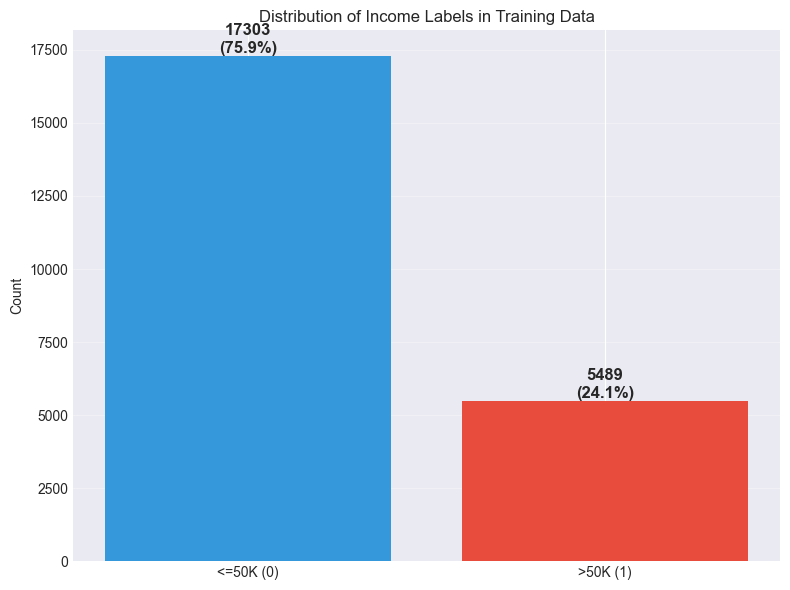

Class distribution:
  <=50K (0): 17303 (75.92%)
  >50K (1): 5489 (24.08%)


In [25]:
# Label distribution
unique, counts = np.unique(train_labels, return_counts=True)
label_dist = dict(zip(unique, counts))

plt.figure(figsize=(8, 6))
plt.bar(['<=50K (0)', '>50K (1)'], [label_dist[0], label_dist[1]], color=['#3498db', '#e74c3c'])
plt.ylabel('Count')
plt.title('Distribution of Income Labels in Training Data')
plt.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(label_dist.items()):
    plt.text(i, count, f'{count}\n({count/sum(counts)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Class distribution:")
print(f"  <=50K (0): {label_dist[0]} ({label_dist[0]/sum(counts)*100:.2f}%)")
print(f"  >50K (1): {label_dist[1]} ({label_dist[1]/sum(counts)*100:.2f}%)")

In [26]:
# Check for missing values
missing_train = train_df.isna().sum()
missing_test = test_df.isna().sum()

# Check for ' ?' values
question_train = (train_df == ' ?').sum()
question_test = (test_df == ' ?').sum()

print("Missing values (NaN) in training data:")
print(missing_train[missing_train > 0])
print("\n' ?' values in training data:")
print(question_train[question_train > 0])

Missing values (NaN) in training data:
Series([], dtype: int64)

' ?' values in training data:
Series([], dtype: int64)


## 3. Data Preprocessing

In [ ]:
# Preprocess data with downsampling to balance classes
print("Preprocessing data with downsampling...")
X_train_scaled, y_train, X_test_scaled, feature_names = preprocessor.preprocess(
    train_df, train_labels, test_df,
    apply_downsampling=True,  # Enable downsampling to balance classes
    random_state=42
)

print(f"\nPreprocessed training data shape (after downsampling): {X_train_scaled.shape}")
print(f"Preprocessed test data shape: {X_test_scaled.shape}")
print(f"Number of features after preprocessing: {len(feature_names)}")

# Verify class balance after downsampling
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nClass distribution after downsampling:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} ({count/len(y_train)*100:.2f}%)")

In [28]:
# Split training data
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 18233
Validation set size: 4559
Test set size: 9769


## 4. Model Architecture

In [29]:
# Create model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_dim = X_train.shape[1]

model = create_model(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32]
)

print("Neural Network Architecture:")
print("="*50)
print(model)
print("="*50)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Neural Network Architecture:
NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
    (7): Softmax(dim=1)
  )
)

Total parameters: 12,322
Trainable parameters: 12,322


## 5. Model Training

In [30]:
# Create trainer
trainer = Trainer(model, device=device, learning_rate=0.00001)

# Train model
print("Training the model...")
history = trainer.fit(
    X_train, y_train_split,
    X_val, y_val,
    epochs=500,
    batch_size=128,
    verbose=True
)

print("\nTraining completed!")

Training the model...
Epoch [5/500], Train Loss: 0.6543, Train Acc: 0.7638, Val Loss: 0.6505, Val Acc: 0.7635
Epoch [10/500], Train Loss: 0.5975, Train Acc: 0.7629, Val Loss: 0.5937, Val Acc: 0.7620
Epoch [15/500], Train Loss: 0.5516, Train Acc: 0.7675, Val Loss: 0.5506, Val Acc: 0.7675
Epoch [20/500], Train Loss: 0.5204, Train Acc: 0.7920, Val Loss: 0.5208, Val Acc: 0.7943
Epoch [25/500], Train Loss: 0.5001, Train Acc: 0.8179, Val Loss: 0.5016, Val Acc: 0.8142
Epoch [30/500], Train Loss: 0.4887, Train Acc: 0.8259, Val Loss: 0.4908, Val Acc: 0.8208
Epoch [35/500], Train Loss: 0.4822, Train Acc: 0.8281, Val Loss: 0.4846, Val Acc: 0.8254
Epoch [40/500], Train Loss: 0.4780, Train Acc: 0.8304, Val Loss: 0.4807, Val Acc: 0.8293
Epoch [45/500], Train Loss: 0.4759, Train Acc: 0.8312, Val Loss: 0.4781, Val Acc: 0.8304
Epoch [50/500], Train Loss: 0.4740, Train Acc: 0.8329, Val Loss: 0.4763, Val Acc: 0.8309
Epoch [55/500], Train Loss: 0.4726, Train Acc: 0.8346, Val Loss: 0.4749, Val Acc: 0.8322


## 6. Training Results Visualization

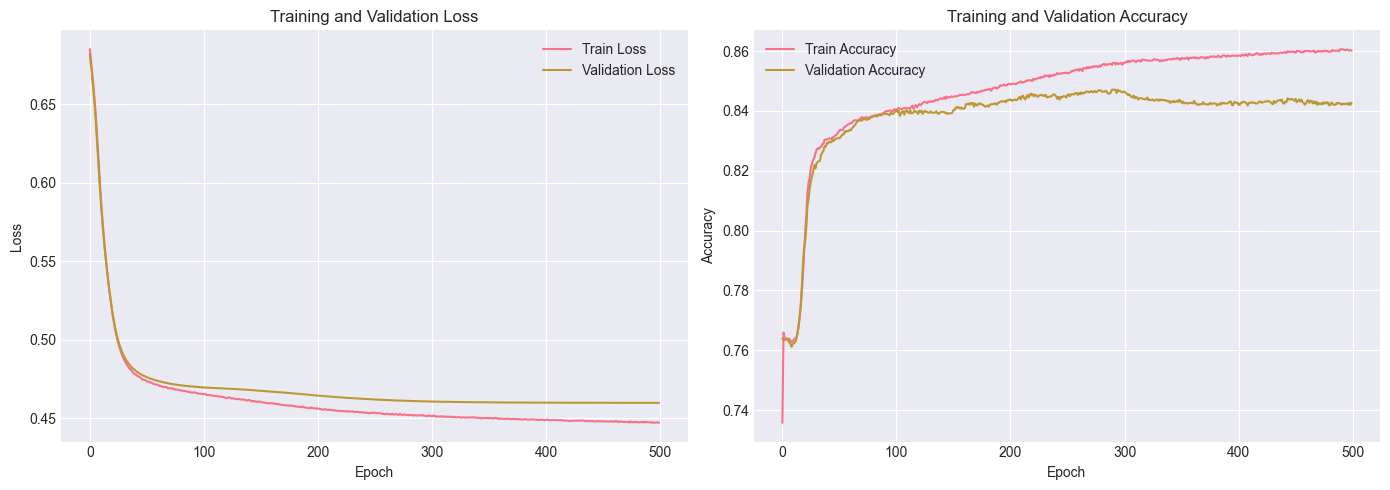

In [31]:
# Plot training history
os.makedirs('figures', exist_ok=True)
trainer.plot_training_history(save_path='figures/training_history.png')
plt.show()

## 7. Model Evaluation

In [32]:
# Evaluate on validation set
metrics, val_predictions = trainer.evaluate(X_val, y_val)

print("Validation Set Metrics:")
print("="*50)
for metric_name, value in metrics.items():
    print(f"{metric_name.capitalize():20s}: {value:.4f}")
print("="*50)

Validation Set Metrics:
Accuracy            : 0.8427
Precision           : 0.7218
Recall              : 0.5647
F1_score            : 0.6336
Roc_auc             : 0.8896


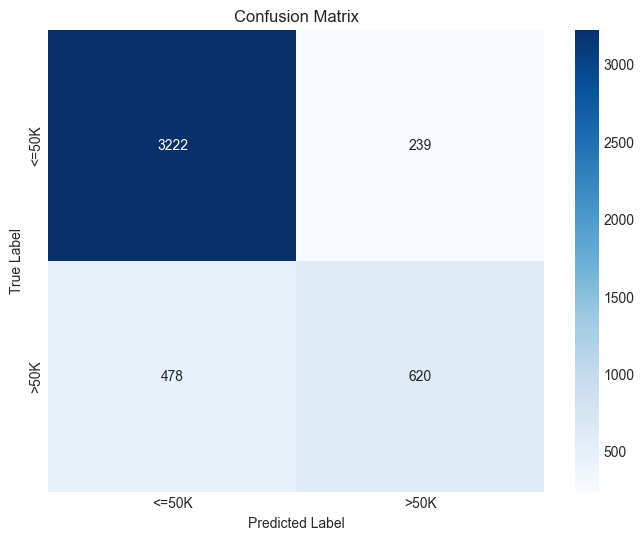

In [33]:
# Confusion Matrix
trainer.plot_confusion_matrix(y_val, val_predictions, save_path='figures/confusion_matrix.png')
plt.show()

In [34]:
# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_val, val_predictions, 
                          target_names=['<=50K', '>50K'],
                          digits=4))


Detailed Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8708    0.9309    0.8999      3461
        >50K     0.7218    0.5647    0.6336      1098

    accuracy                         0.8427      4559
   macro avg     0.7963    0.7478    0.7667      4559
weighted avg     0.8349    0.8427    0.8357      4559



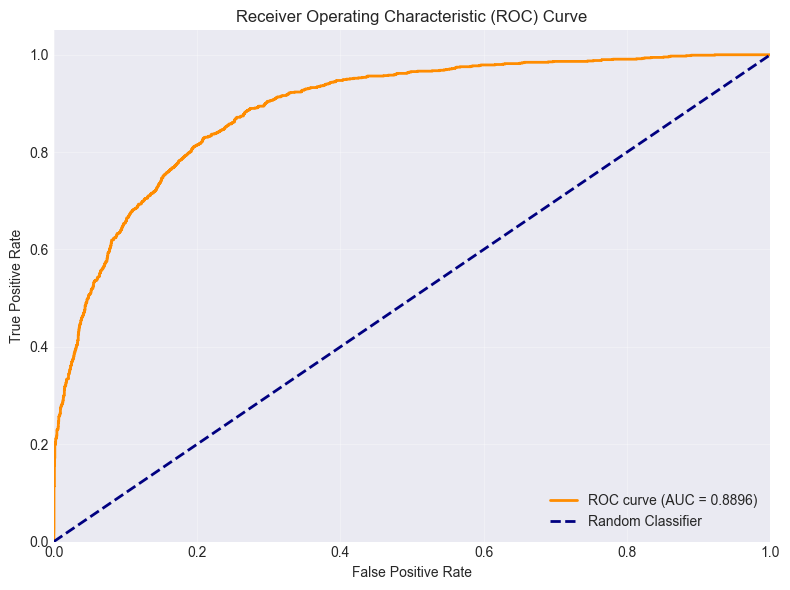

In [35]:
# ROC Curve
val_probabilities = trainer.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(y_val, val_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Test Set Predictions

In [36]:
# Make predictions on test set
test_predictions = trainer.predict(X_test_scaled)

print(f"Test set predictions generated: {len(test_predictions)} samples")

# Prediction distribution
unique, counts = np.unique(test_predictions, return_counts=True)
print("\nTest Set Prediction Distribution:")
for label, count in zip(unique, counts):
    class_name = '<=50K' if label == 0 else '>50K'
    print(f"  {class_name} ({label}): {count} ({count/len(test_predictions)*100:.2f}%)")

Test set predictions generated: 9769 samples

Test Set Prediction Distribution:
  <=50K (0): 7804 (79.89%)
  >50K (1): 1965 (20.11%)


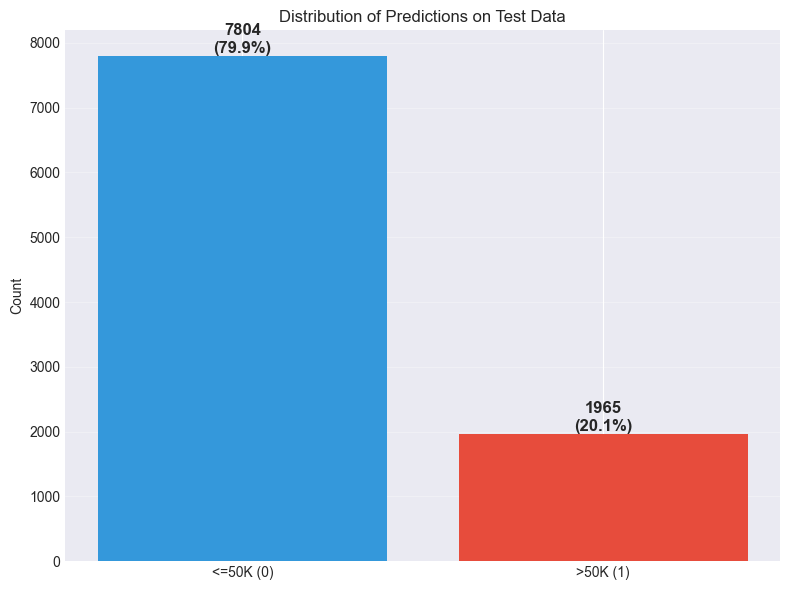

In [37]:
# Visualize test predictions
plt.figure(figsize=(8, 6))
plt.bar(['<=50K (0)', '>50K (1)'], counts, color=['#3498db', '#e74c3c'])
plt.ylabel('Count')
plt.title('Distribution of Predictions on Test Data')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(counts):
    plt.text(i, count, f'{count}\n({count/len(test_predictions)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/test_predictions_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Save Predictions

In [38]:
# Save predictions to file
output_path = 'testlabel.txt'
with open(output_path, 'w') as f:
    for pred in test_predictions:
        f.write(f"{pred}\n")

print(f"✓ Predictions saved to: {output_path}")

✓ Predictions saved to: testlabel.txt


## 10. Summary Statistics for Report

In [39]:
# Create summary table
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1_score']:.4f}",
        f"{metrics['roc_auc']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nModel Performance Summary:")
print(summary_df.to_string(index=False))

# Save to CSV for LaTeX table
summary_df.to_csv('figures/performance_metrics.csv', index=False)
print("\n✓ Performance metrics saved to figures/performance_metrics.csv")


Model Performance Summary:
   Metric  Value
 Accuracy 0.8427
Precision 0.7218
   Recall 0.5647
 F1-Score 0.6336
  ROC-AUC 0.8896

✓ Performance metrics saved to figures/performance_metrics.csv


In [40]:
# Model configuration summary
config_data = {
    'Parameter': ['Input Dimensions', 'Hidden Layers', 'Dropout Rate', 
                  'Learning Rate', 'Batch Size', 'Epochs', 'Optimizer'],
    'Value': [
        f"{input_dim}",
        "[128, 64, 32]",
        "0.3",
        "0.001",
        "128",
        "50",
        "Adam"
    ]
}

config_df = pd.DataFrame(config_data)
print("\nModel Configuration:")
print(config_df.to_string(index=False))

config_df.to_csv('figures/model_configuration.csv', index=False)
print("\n✓ Model configuration saved to figures/model_configuration.csv")


Model Configuration:
       Parameter         Value
Input Dimensions            14
   Hidden Layers [128, 64, 32]
    Dropout Rate           0.3
   Learning Rate         0.001
      Batch Size           128
          Epochs            50
       Optimizer          Adam

✓ Model configuration saved to figures/model_configuration.csv
